# # 📊 Solar Energy & Weather Dataset — Column Reference

## 🌍 Location & Coordinates
- **Site**: Name of the monitoring site / station  
- **Region**: Geographic region  
- **Date**: Observation date  

---

## 🌡️ Temperature
- **Air Temperature (C°)**: Ambient air temperature in degrees Celsius  

---

## ☀️ Solar Irradiance
- **DHI (Wh/m²)**: Diffuse Horizontal Irradiance — scattered solar radiation reaching a horizontal surface  

- **DNI (Wh/m²)**: Direct Normal Irradiance — solar radiation received perpendicular to the sun's rays  

- **GHI (Wh/m²)**: Global Horizontal Irradiance — total solar radiation on a horizontal surface (DHI + DNI × cos θ)  

---

## 💧 Humidity
- **Relative Humidity (%)**: Relative humidity as a percentage of saturation   

---

## 🌬️ Atmospheric Pressure
- **Barometric Pressure (mB (hPa equiv))**: Barometric pressure in millibars (equivalent to hPa)   

---


# Project Workflow

1. Time Series Exploration
2. Value Distribution Analysis
3. Stationarity Testing
4. Time Series Decomposition
5. Series Preprocessing  
6. Train/Test Split
7. Model Building & Comparison
8. Best Model Selection


In [ ]:
import warnings
import itertools
import pickle

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from math import sqrt
from sklearn.metrics import mean_squared_error, mean_absolute_error

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True


# # 1 — Time Series Exploration

In [ ]:
df = pd.read_csv('/content/full_solar_dataset.csv')

df.head()

,Unnamed: 0,Site,Latitude,Longitude,Date,Air Temperature (C°),Air Temperature Uncertainty (C°),DHI (Wh/m2),DHI Uncertainty (Wh/m2),Standard Deviation DHI (Wh/m2),...,Wind Speed at 3m (m/s),Wind Speed at 3m Uncertainty (m/s),Wind Speed at 3m (std dev) (m/s),Wind Speed at 3m (std dev) Uncertainty (m/s),Peak Wind Speed at 3m (m/s),Peak Wind Speed at 3m Uncertainty (m/s),DHI,Diffuse horizontal measurement for solar monitoring data,ALLOW NULL,float
0,0,Abha - TVTC,18.2227,42.546,01/01/2017 00:00:00,14.3,0.5,1016.6,269.7,302.6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,Abha - TVTC,18.2227,42.546,01/02/2017 00:00:00,13.6,0.5,1723.8,579.7,852.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,Abha - TVTC,18.2227,42.546,01/03/2017 00:00:00,16.5,0.5,2015.2,602.6,833.9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,Abha - TVTC,18.2227,42.546,01/04/2017 00:00:00,19.5,0.5,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,Abha - TVTC,18.2227,42.546,01/05/2017 00:00:00,20.9,0.5,2451.5,186.9,571.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.shape

(2099, 33)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2099 entries, 0 to 2098
Data columns (total 33 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Unnamed: 0                                                2099 non-null   int64  
 1   Site                                                      1930 non-null   object 
 2   Latitude                                                  1930 non-null   float64
 3   Longitude                                                 1930 non-null   float64
 4   Date                                                      1930 non-null   object 
 5   Air Temperature (C°)                                      1891 non-null   float64
 6   Air Temperature Uncertainty (C°)                          1891 non-null   float64
 7   DHI (Wh/m2)                                               1865 non-null   float64
 8   DHI Uncertainty (W

In [ ]:
df_solar = df[['Site', 'Region', 'Date', 'Air Temperature (C°)', 'DHI (Wh/m2)', 'GHI (Wh/m2)','DNI (Wh/m2)']]

df_solar.head()

,Site,Region,Date,Air Temperature (C°),DHI (Wh/m2),GHI (Wh/m2),DNI (Wh/m2)
0,Abha - TVTC,Abha Technical Institute-Monthly Data,01/01/2017 00:00:00,14.3,1016.6,5111.2,7075.4
1,Abha - TVTC,Abha Technical Institute-Monthly Data,01/02/2017 00:00:00,13.6,1723.8,4087.9,3633.6
2,Abha - TVTC,Abha Technical Institute-Monthly Data,01/03/2017 00:00:00,16.5,2015.2,5744.1,5422.2
3,Abha - TVTC,Abha Technical Institute-Monthly Data,01/04/2017 00:00:00,19.5,NaN,NaN,6293.1
4,Abha - TVTC,Abha Technical Institute-Monthly Data,01/05/2017 00:00:00,20.9,2451.5,6345.9,5004.4


In [ ]:
df_solar= df_solar.fillna(df_solar.mean(numeric_only=True))

In [ ]:
df_solar.isna().sum() / len(df_solar)*100

,0
Site,8.051453
Region,0.000000
Date,8.051453
Air Temperature (C°),0.000000
DHI (Wh/m2),0.000000
GHI (Wh/m2),0.000000
DNI (Wh/m2),0.000000


# Data Preprocessing

In [ ]:
df_solar['Date'] = pd.to_datetime(df_solar['Date'], dayfirst=True, errors='coerce')

In [ ]:
df_solar = df_solar.sort_values(['Site','Date']).reset_index(drop=True)

In [ ]:
(df_solar['Region'] == 'Metadata').sum()

np.int64(169)

In [ ]:
df_solar = df_solar[df_solar['Region'] != 'Metadata']

In [ ]:
df_solar['Region'].value_counts()

,count
Region,
Abha Technical Institute-Monthly Data,51
Al Hanakiyah Technical Institute-Monthly Data,51
Al Dawadmi College of Technology-Monthly Data,51
Al Aflaaj Technical Institute-Monthly Data,51
Najran University-Monthly Data,51
Najran University-Monthly Data (1),51
Saline Water Conversion Corporation (Hagl)-Monthly Data,51
King Abdulaziz University East Hada Alsham Campus-Monthly Data,51
Duba Technical Institute-Monthly Data,51


In [ ]:
df_solar.isna().sum() / len(df_solar)*100

,0
Site,0.0
Region,0.0
Date,0.0
Air Temperature (C°),0.0
DHI (Wh/m2),0.0
GHI (Wh/m2),0.0
DNI (Wh/m2),0.0


In [ ]:
df_solar.describe()

,Date,Air Temperature (C°),DHI (Wh/m2),GHI (Wh/m2),DNI (Wh/m2)
count,1930,1930.000000,1930.000000,1930.000000,1930.000000
mean,2019-07-18 08:25:07.150258944,26.414543,2147.774155,5966.679818,5697.055117
min,2017-01-01 00:00:00,5.400000,348.600000,3033.700000,0.300000
25%,2018-06-01 00:00:00,21.300000,1616.750000,4963.650000,4820.725000
50%,2019-08-01 00:00:00,26.750000,2113.500000,6094.300000,5697.055117
75%,2020-11-01 00:00:00,31.900000,2608.325000,6939.275000,6572.600000
max,2021-12-01 00:00:00,40.100000,6394.600000,8380.700000,9517.000000
std,NaN,6.631326,672.374840,1210.066575,1330.098678


# Missing Date Imputation — Handled via Linear Interpolation  

In [ ]:
full_range = pd.date_range(start='2017-01-01', end='2021-12-01', freq='MS')

all_cities = []

for city in df_solar['Site'].unique():

    # Skip missing/null city entries
    if pd.isna(city):
        continue

    city_df = df_solar[df_solar['Site'] == city].copy()

    region = city_df['Region'].dropna().values
    if len(region) == 0:
        continue
    region = region[0]

    # Build a complete 60-month date range for this city
    full_df = pd.DataFrame({'Date': full_range})
    full_df['Site']   = city
    full_df['Region'] = region

    # Merge with the city's actual data
    city_full = full_df.merge(city_df, on=['Date', 'Site', 'Region'], how='left')

    # Interpolate missing values in numeric columns only
    num_cols = city_full.select_dtypes(include='number').columns
    city_full[num_cols] = city_full[num_cols].infer_objects(copy=False)
    city_full[num_cols] = city_full[num_cols].interpolate(
        method='linear', limit_direction='both'
    )

    all_cities.append(city_full)

# Concatenate all cities into a single DataFrame
df_solar = pd.concat(all_cities, ignore_index=True)
df_solar = df_solar.sort_values(['Site', 'Date']).reset_index(drop=True)

print(f"Final shape: {df_solar.shape}")

Final shape: (2520, 7)


In [ ]:
# Verify each city has exactly 60 monthly records
counts = df_solar.groupby('Site')['Date'].count()
print(counts)
print(f"\nAll cities complete? {(counts == 60).all()}")

# Confirm there are no remaining missing values
print(f"Missing values: {df_solar.isnull().sum().sum()}")

# # Last 15 rows (commented out)
# print(df_solar.tail(15))

Site
Abha - TVTC                    60
Afif - TVTC                    60
Al Ahsa - KFU                  60
Al Baha - University           60
Al Dawadmi - TVTC              60
Al Farshah - TQ TVTC           60
Al Hanakiyah - TVTC            60
Al Jouf - TVTC                 60
Al Jubail - SWCC               60
Al Khafji - SWCC               60
Al Uwayqilah                   60
Al Wajh - TVTC                 60
Arar - TVTC                    60
Dammam - IAFU                  60
Duba - TVTC                    60
Farasan - SWCC                 60
Hada Al Sham - KAU             60
Hagl - SWCC                    60
Hail - TVTC                    60
Jazan - University             60
Layla - TVTC                   60
Madinah - Taibah University    60
Mahd ad Dahab                  60
Majmaah - University           60
Makkah - UQU                   60
Najran - University            60
Osfan - KAU                    60
Qassim - University            60
Rania - TVTC                   60
Riyadh - 

## Aggregation at the National Level

Aggregate all regional observations into a single monthly dataset representing Saudi Arabia.

In [ ]:
# Aggregate all regions into a national monthly average
saudi_df = df_solar.groupby('Date')[['GHI (Wh/m2)', 'DNI (Wh/m2)',
                                      'DHI (Wh/m2)',
                                      'Air Temperature (C°)']].mean().reset_index()

# Add a column to label the aggregated region
saudi_df['Region_Group'] = 'Saudi Arabia'

saudi_df = saudi_df.sort_values('Date').reset_index(drop=True)

print(saudi_df.shape)
saudi_df.head(10)

(60, 6)


,Date,GHI (Wh/m2),DNI (Wh/m2),DHI (Wh/m2),Air Temperature (C°),Region_Group
0,2017-01-01,4628.450459,5369.687270,1581.849920,18.769740,Saudi Arabia
1,2017-02-01,4818.360724,4501.867773,2041.120522,17.639120,Saudi Arabia
2,2017-03-01,5566.384148,4524.421980,2425.796657,22.500069,Saudi Arabia
3,2017-04-01,6335.762814,4789.527693,2790.423408,27.142188,Saudi Arabia
4,2017-05-01,6693.242913,5014.571862,2870.024583,30.295128,Saudi Arabia
5,2017-06-01,6934.305387,6180.496970,2420.626338,31.054443,Saudi Arabia
6,2017-07-01,6771.892395,6126.920227,2349.298619,31.074926,Saudi Arabia
7,2017-08-01,6609.479402,6073.343483,2277.970900,31.095409,Saudi Arabia
8,2017-09-01,6447.066410,6019.766740,2206.643181,31.115893,Saudi Arabia
9,2017-10-01,5883.481661,6626.871501,1665.234213,27.736657,Saudi Arabia


In [ ]:
saudi_df.tail()

,Date,GHI (Wh/m2),DNI (Wh/m2),DHI (Wh/m2),Air Temperature (C°),Region_Group
55,2021-08-01,6762.708367,6041.961117,2321.781292,33.840792,Saudi Arabia
56,2021-09-01,6376.439348,6007.222597,2137.221536,31.765122,Saudi Arabia
57,2021-10-01,5746.750459,6316.376434,1710.621963,28.437099,Saudi Arabia
58,2021-11-01,4804.332853,6042.108455,1393.468432,23.650000,Saudi Arabia
59,2021-12-01,4297.952840,5114.810011,1534.507062,20.141861,Saudi Arabia


In [ ]:
saudi_df = saudi_df.set_index('Date')

Text(0.5, 1.0, 'Saudi Arabia GHI (Wh/m2)')

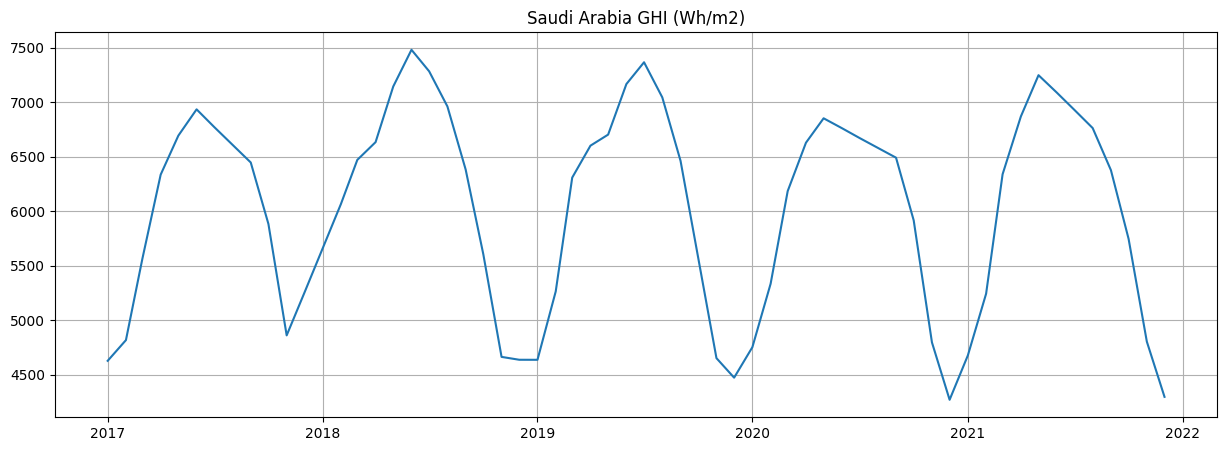

In [ ]:
plt.figure(figsize=(15,5))

plt.plot(saudi_df['GHI (Wh/m2)'])
plt.title('Saudi Arabia GHI (Wh/m2)')


Text(0.5, 1.0, 'Saudi Arabia GHI (Wh/m2)')

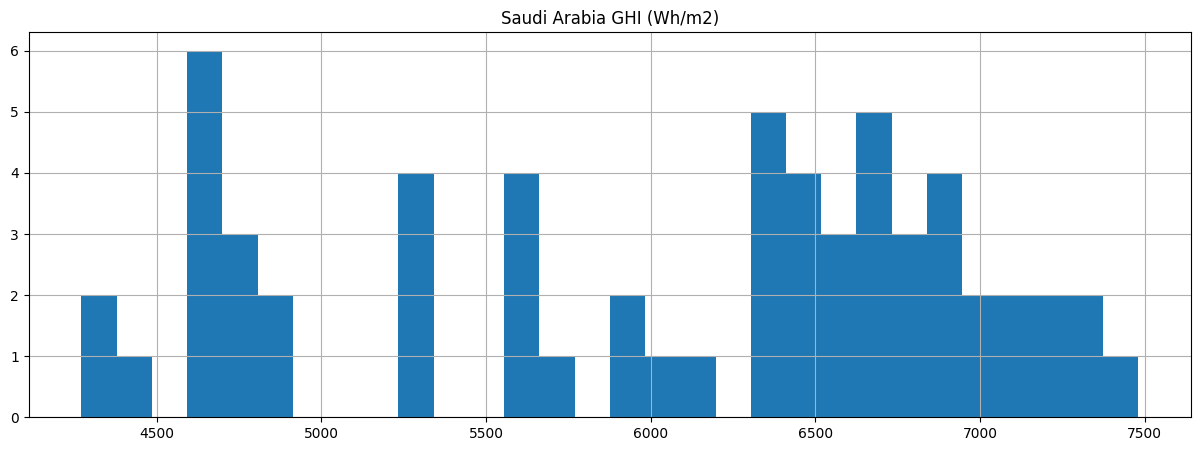

In [ ]:
plt.figure(figsize=(15,5))

plt.hist(saudi_df['GHI (Wh/m2)'] ,bins=30)
plt.title('Saudi Arabia GHI (Wh/m2)')


Text(0.5, 1.0, 'Saudi Arabia GHI (Wh/m2)')

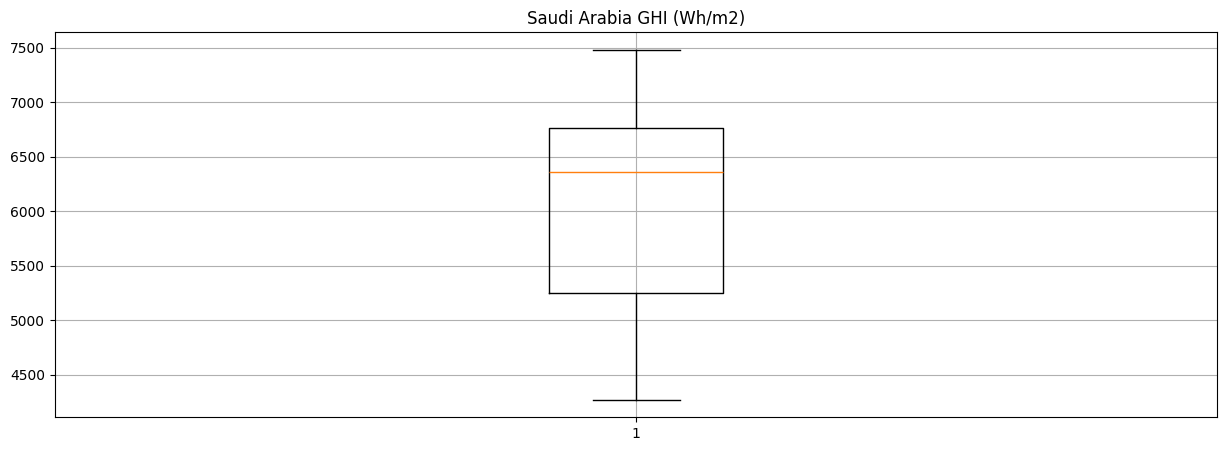

In [ ]:
plt.figure(figsize=(15,5))

plt.boxplot(saudi_df['GHI (Wh/m2)'])
plt.title('Saudi Arabia GHI (Wh/m2)')


# Stationarity Testing

In [ ]:
def adf_report(x, title="ADF Test"):
    x = x.dropna()
    result = adfuller(x)

    stat = result[0]
    p_value = result[1]
    used_lag = result[2]
    n_obs = result[3]
    critical_values = result[4]

    print(f"===== {title} =====")
    print(f"ADF Statistic : {stat:.6f}")
    print(f"p-value       : {p_value:.6f}")
    print(f"Used Lag      : {used_lag}")
    print(f"N Observations: {n_obs}")
    print("Critical Values:")
    for key, value in critical_values.items():
        print(f"   {key}: {value:.6f}")

    if p_value <= 0.05:
        print("Conclusion    : Series is stationary ✅")
    else:
        print("Conclusion    : Series is non-stationary ❌")

In [ ]:
adf_report(saudi_df['GHI (Wh/m2)'], "ADF on Original Series")

===== ADF on Original Series =====
ADF Statistic : -2.186325
p-value       : 0.211246
Used Lag      : 10
N Observations: 49
Critical Values:
   1%: -3.571472
   5%: -2.922629
   10%: -2.599336
Conclusion    : Series is non-stationary ❌


## ACF and PACF Analysis


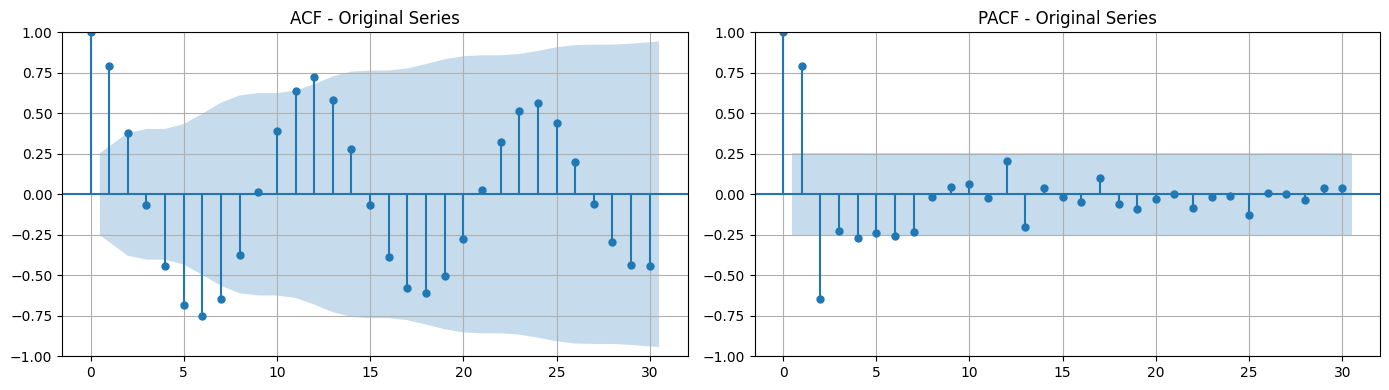

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(saudi_df['GHI (Wh/m2)'].dropna(), lags=30, ax=ax[0])
ax[0].set_title("ACF - Original Series")

plot_pacf(saudi_df['GHI (Wh/m2)'].dropna(), lags=30, method='ywm', ax=ax[1])
ax[1].set_title("PACF - Original Series")

plt.tight_layout()
plt.show()

# Time Series Decomposition

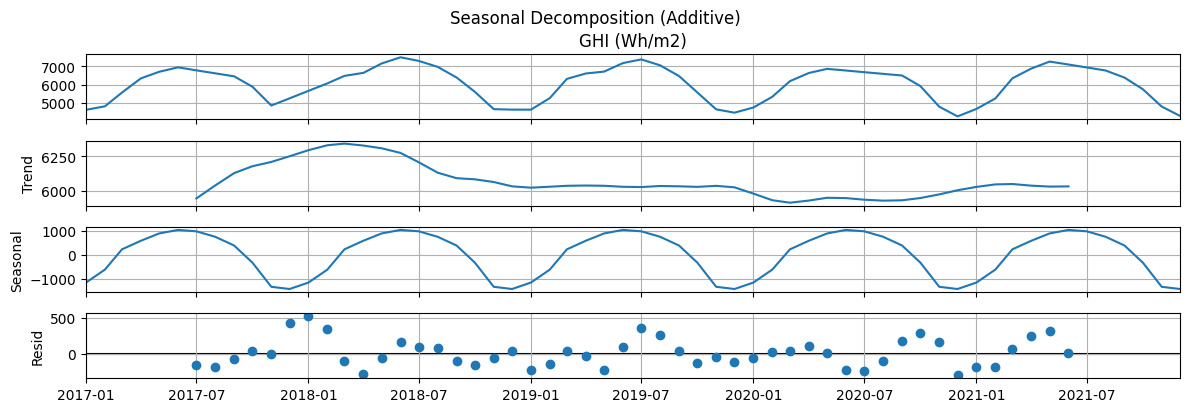

In [ ]:
period_guess = 12

decomp = seasonal_decompose(saudi_df['GHI (Wh/m2)'].dropna(), model='additive', period=period_guess)
decomp.plot()
plt.suptitle("Seasonal Decomposition (Additive)", y=1.02)
plt.show()

In [ ]:
# First-order differencing
series_d1 = saudi_df['GHI (Wh/m2)'].diff()

# Seasonal differencing
series_D1 = saudi_df['GHI (Wh/m2)'].diff(period_guess)

# Combined first-order and seasonal differencing
series_d1_D1 = saudi_df['GHI (Wh/m2)'].diff().diff(period_guess)

In [ ]:
adf_report(series_d1, "ADF after 1st Difference")
print()
adf_report(series_D1, f"ADF after Seasonal Difference (s={period_guess})")
print()
adf_report(series_d1_D1, f"ADF after 1st + Seasonal Difference (s={period_guess})")

===== ADF after 1st Difference =====
ADF Statistic : -3.180068
p-value       : 0.021168
Used Lag      : 11
N Observations: 47
Critical Values:
   1%: -3.577848
   5%: -2.925338
   10%: -2.600774
Conclusion    : Series is stationary ✅

===== ADF after Seasonal Difference (s=12) =====
ADF Statistic : -4.353690
p-value       : 0.000358
Used Lag      : 10
N Observations: 37
Critical Values:
   1%: -3.620918
   5%: -2.943539
   10%: -2.610400
Conclusion    : Series is stationary ✅

===== ADF after 1st + Seasonal Difference (s=12) =====
ADF Statistic : -7.432049
p-value       : 0.000000
Used Lag      : 1
N Observations: 45
Critical Values:
   1%: -3.584829
   5%: -2.928299
   10%: -2.602344
Conclusion    : Series is stationary ✅


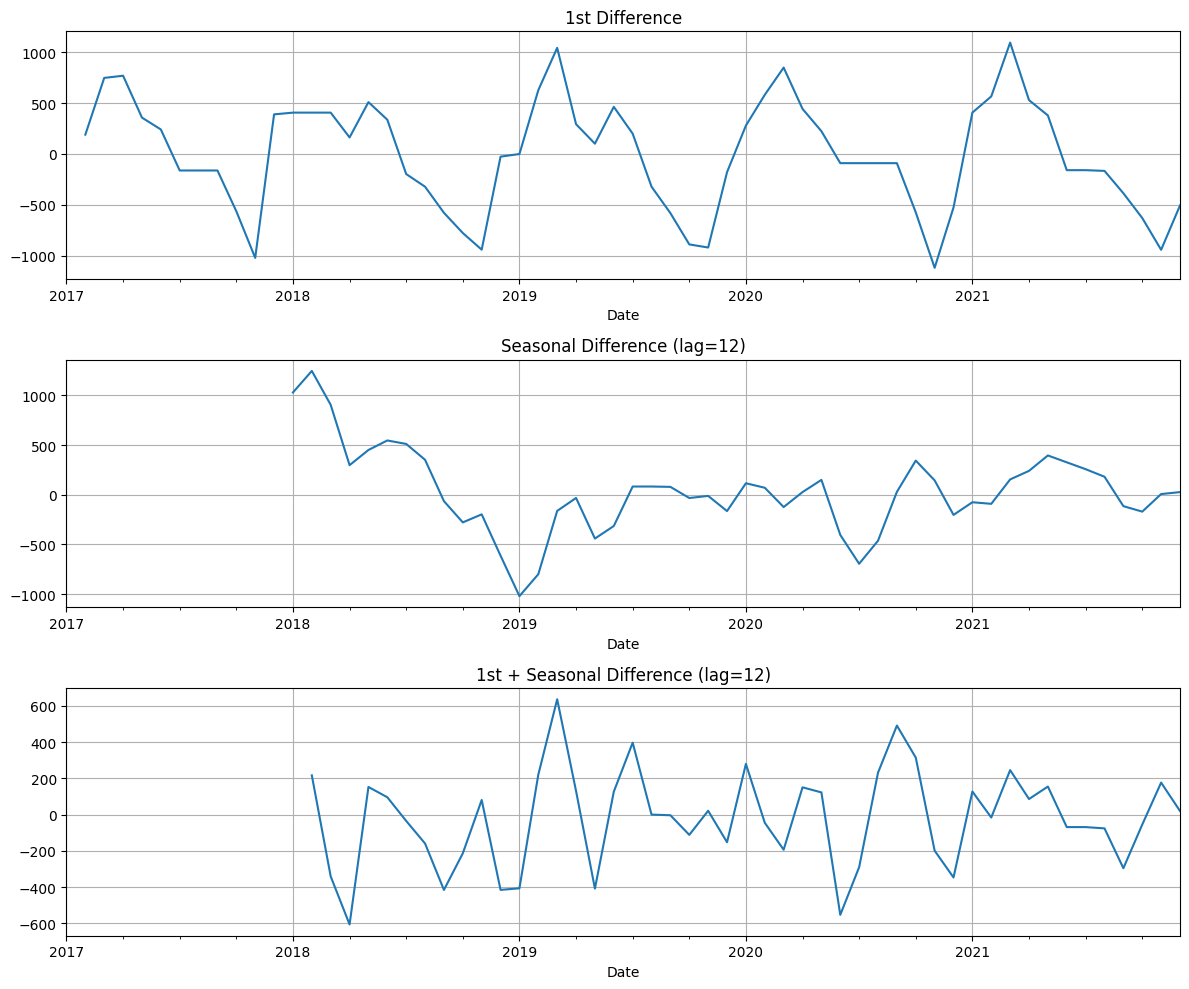

In [ ]:
fig, ax = plt.subplots(3, 1, figsize=(12, 10))

series_d1.plot(ax=ax[0], title="1st Difference")
series_D1.plot(ax=ax[1], title=f"Seasonal Difference (lag={period_guess})")
series_d1_D1.plot(ax=ax[2], title=f"1st + Seasonal Difference (lag={period_guess})")

plt.tight_layout()
plt.show()

In [ ]:
# saudi_df['GHI (Wh/m2)'] = saudi_df['GHI (Wh/m2)'].diff()
# adf_report(saudi_df['GHI (Wh/m2)'], "ADF after Differencing")

# Train / Test Split

In [ ]:
split_idx = int(len(saudi_df['GHI (Wh/m2)']) * 0.66)
train = saudi_df['GHI (Wh/m2)'].iloc[:split_idx]
test = saudi_df['GHI (Wh/m2)'].iloc[split_idx:]

print("Train size:", len(train))
print("Test size :", len(test))

Train size: 39
Test size : 21


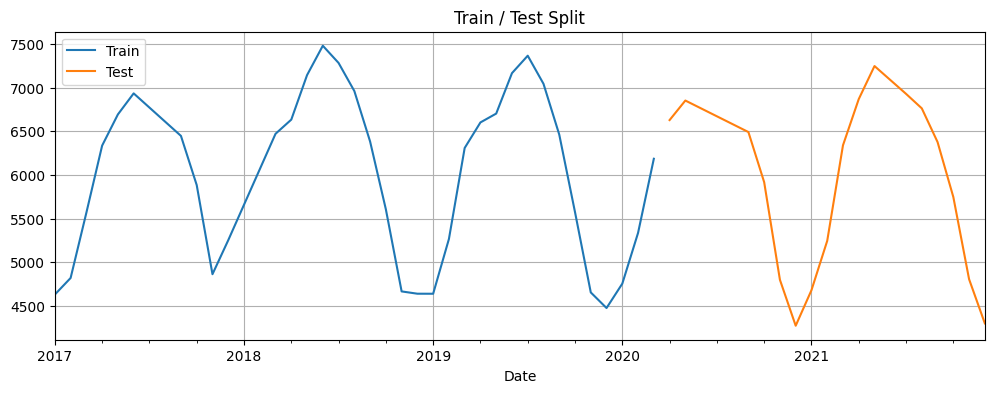

In [ ]:
plt.figure(figsize=(12, 4))
train.plot(label="Train")
test.plot(label="Test")
plt.title("Train / Test Split")
plt.legend()
plt.show()

In [ ]:
def rmse(y_true, y_pred):
    return sqrt(mean_squared_error(y_true, y_pred))

def mae(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred)

# Baseline Model

In [ ]:
baseline_pred = test.shift(1).fillna(train.iloc[-1])

baseline_rmse = rmse(test.values, baseline_pred.values)
baseline_mae = mae(test.values, baseline_pred.values)

print("Baseline RMSE:", baseline_rmse)
print("Baseline MAE :", baseline_mae)

Baseline RMSE: 535.2808128389646
Baseline MAE : 436.8851082964712


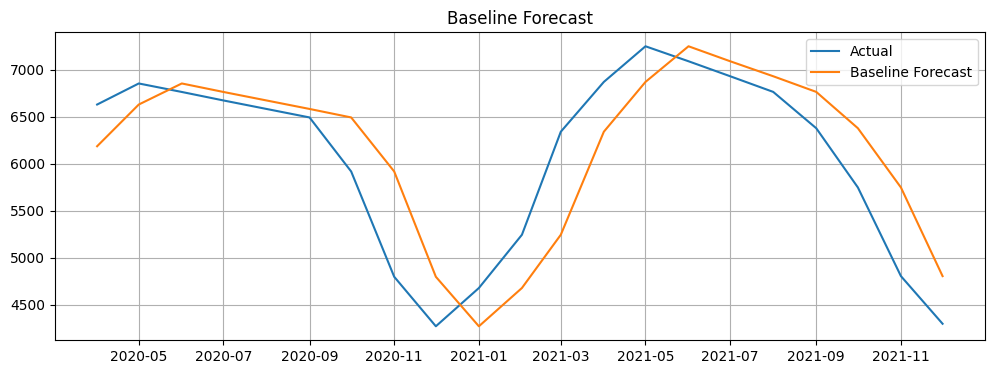

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(test.index, test.values, label="Actual")
plt.plot(test.index, baseline_pred.values, label="Baseline Forecast")
plt.title("Baseline Forecast")
plt.legend()
plt.show()

# Models Used

## 1 — Statistical Models
* ARMA
* ARIMA
* SARIMA

## 2 — Machine Learning Models
* Linear Regression
* XGBoost
* Random Forest
* Gradient Boosting
## 3 — Deep Learning Models

In [ ]:
train_diff = train.diff().dropna()

p_range = range(0, 4)
q_range = range(0, 4)

best_arma_aic = np.inf
best_arma_order = None
arma_models = {}

for p in p_range:
    for q in q_range:
        if p == 0 and q == 0:
            continue
        try:
            model = ARIMA(train_diff, order=(p, 0, q)).fit()
            arma_models[(p, q)] = model

            if model.aic < best_arma_aic:
                best_arma_aic = model.aic
                best_arma_order = (p, q)
        except:
            pass

print("Best ARMA order:", best_arma_order)
print("Best ARMA AIC  :", round(best_arma_aic, 3))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_date

Best ARMA order: (2, 3)
Best ARMA AIC  : 553.204


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
arma_best = arma_models[best_arma_order]
print(arma_best.summary())

                               SARIMAX Results                                
Dep. Variable:            GHI (Wh/m2)   No. Observations:                   38
Model:                 ARIMA(2, 0, 3)   Log Likelihood                -269.602
Date:                Sun, 31 May 2026   AIC                            553.204
Time:                        21:53:48   BIC                            564.667
Sample:                    02-01-2017   HQIC                           557.283
                         - 03-01-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         18.0453     42.436      0.425      0.671     -65.128     101.219
ar.L1          1.7264      0.031     54.999      0.000       1.665       1.788
ar.L2         -0.9897      0.024    -41.337      0.0

In [ ]:
nsteps = len(test)
arma_diff_forecast = arma_best.get_forecast(steps=nsteps).predicted_mean

last_train_level = train.iloc[-1]
arma_forecast = last_train_level + arma_diff_forecast.cumsum()

arma_rmse = rmse(test.values, arma_forecast.values)
arma_mae = mae(test.values, arma_forecast.values)

print("ARMA RMSE:", arma_rmse)
print("ARMA MAE :", arma_mae)

ARMA RMSE: 496.17177690501893
ARMA MAE : 423.8401432955773


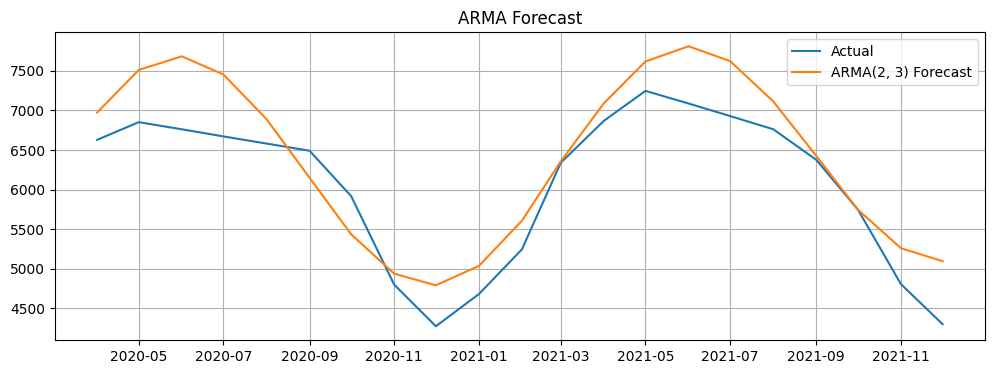

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(test.index, test.values, label="Actual")
plt.plot(test.index, arma_forecast.values, label=f"ARMA{best_arma_order} Forecast")
plt.title("ARMA Forecast")
plt.legend()
plt.show()

In [ ]:
p = range(0, 4)
d = [0, 1, 2]
q = range(0, 4)

best_arima_aic = np.inf
best_arima_order = None
arima_models = {}

for order in itertools.product(p, d, q):
    try:
        model = ARIMA(train, order=order).fit()
        arima_models[order] = model

        if model.aic < best_arima_aic:
            best_arima_aic = model.aic
            best_arima_order = order
    except:
        pass

print("Best ARIMA order:", best_arima_order)
print("Best ARIMA AIC  :", round(best_arima_aic, 3))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_date

Best ARIMA order: (3, 1, 3)
Best ARIMA AIC  : 553.386


In [ ]:
arima_best = arima_models[best_arima_order]
print(arima_best.summary())

                               SARIMAX Results                                
Dep. Variable:            GHI (Wh/m2)   No. Observations:                   39
Model:                 ARIMA(3, 1, 3)   Log Likelihood                -269.693
Date:                Sun, 31 May 2026   AIC                            553.386
Time:                        21:53:56   BIC                            564.849
Sample:                    01-01-2017   HQIC                           557.464
                         - 03-01-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.2291      0.514      2.391      0.017       0.222       2.237
ar.L2         -0.1267      0.882     -0.144      0.886      -1.856       1.602
ar.L3         -0.4979      0.504     -0.987      0.3

In [ ]:
arima_fc = arima_best.get_forecast(steps=len(test))
arima_forecast = arima_fc.predicted_mean

arima_rmse = rmse(test.values, arima_forecast.values)
arima_mae = mae(test.values, arima_forecast.values)

print("ARIMA RMSE:", arima_rmse)
print("ARIMA MAE :", arima_mae)

ARIMA RMSE: 359.24878704500316
ARIMA MAE : 307.20126574137515


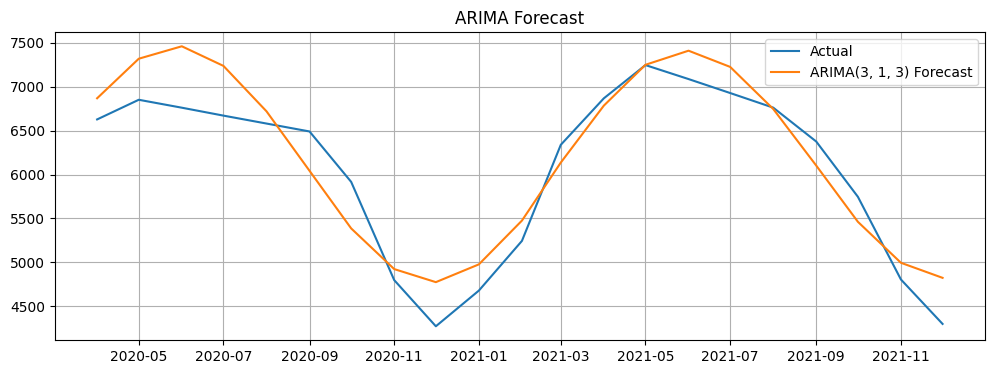

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(test.index, test.values, label="Actual")
plt.plot(test.index, arima_forecast.values, label=f"ARIMA{best_arima_order} Forecast")
plt.title("ARIMA Forecast")
plt.legend()
plt.show()

In [ ]:
p = range(0, 4)
d = [0, 1]
q = range(0, 4)

P = range(0, 3)
D = [0, 1]
Q = range(0, 3)
s = period_guess

best_sarima_aic = np.inf
best_sarima_cfg = None
sarima_models = {}

for order in itertools.product(p, d, q):
    for seasonal_order in itertools.product(P, D, Q, [s]):
        try:
            model = SARIMAX(
                train,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False
            ).fit(disp=False)

            sarima_models[(order, seasonal_order)] = model

            if model.aic < best_sarima_aic:
                best_sarima_aic = model.aic
                best_sarima_cfg = (order, seasonal_order)
        except:
            pass

print("Best SARIMA config:", best_sarima_cfg)
print("Best SARIMA AIC   :", round(best_sarima_aic, 3))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Li

Best SARIMA config: ((0, 1, 0), (2, 1, 0, 12))
Best SARIMA AIC   : -36.703


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used

In [ ]:
sarima_best = sarima_models[best_sarima_cfg]
print(sarima_best.summary())

                                     SARIMAX Results                                      
Dep. Variable:                        GHI (Wh/m2)   No. Observations:                   39
Model:             SARIMAX(0, 1, 0)x(2, 1, 0, 12)   Log Likelihood                  21.351
Date:                            Sun, 31 May 2026   AIC                            -36.703
Time:                                    21:57:13   BIC                            -40.623
Sample:                                01-01-2017   HQIC                           -44.902
                                     - 03-01-2020                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.S.L12      -0.2696      0.014    -19.266      0.000      -0.297      -0.242
ar.S.L24       0.0656      0.008   

In [ ]:
sarima_fc = sarima_best.get_forecast(steps=len(test))
sarima_forecast = sarima_fc.predicted_mean
sarima_ci = sarima_fc.conf_int()

sarima_rmse = rmse(test.values, sarima_forecast.values)
sarima_mae = mae(test.values, sarima_forecast.values)

print("SARIMA RMSE:", sarima_rmse)
print("SARIMA MAE :", sarima_mae)

SARIMA RMSE: 395.41053056865417
SARIMA MAE : 339.3503281928553


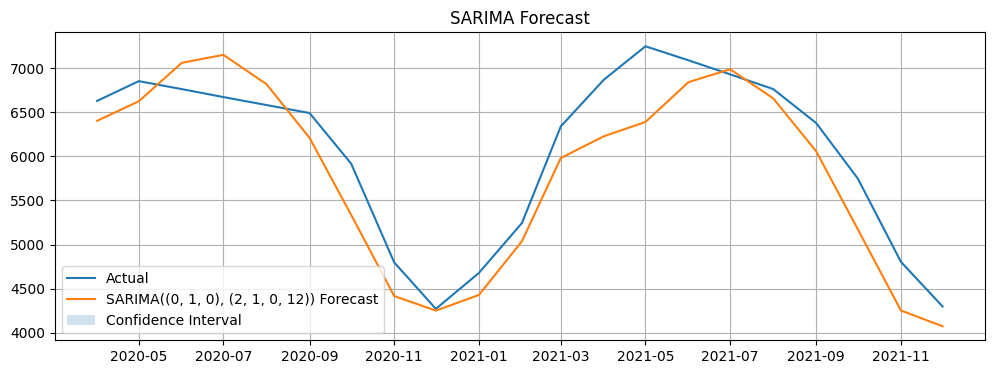

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(test.index, test.values, label="Actual")
plt.plot(test.index, sarima_forecast.values, label=f"SARIMA{best_sarima_cfg} Forecast")
plt.fill_between(test.index, sarima_ci.iloc[:, 0], sarima_ci.iloc[:, 1], alpha=0.2, label="Confidence Interval")
plt.title("SARIMA Forecast")
plt.legend()
plt.show()

## Model Comparison

Models will be compared using the following metrics:

- **RMSE**
- **MAE**
- **AIC** for statistical models

In [ ]:
results = pd.DataFrame({
    "Model": ["Baseline", "ARMA", "ARIMA", "SARIMA"],
    "RMSE": [
        baseline_rmse,
        arma_rmse,
        arima_rmse,
        sarima_rmse
    ],
    "MAE": [
        baseline_mae,
        arma_mae,
        arima_mae,
        sarima_mae
    ],
    "AIC": [
        np.nan,
        float(arma_best.aic),
        float(arima_best.aic),
        float(sarima_best.aic)
    ],
    "Description": [
        "Persistence baseline",
        "ARMA on differenced series",
        "Handles non-seasonal trend",
        "Handles trend + seasonality"
    ]
})

results = results.sort_values("RMSE", ascending=True)
display(results)

,Model,RMSE,MAE,AIC,Description
2,ARIMA,359.248787,307.201266,553.385669,Handles non-seasonal trend
3,SARIMA,395.410531,339.350328,-36.702911,Handles trend + seasonality
1,ARMA,496.171777,423.840143,553.204376,ARMA on differenced series
0,Baseline,535.280813,436.885108,NaN,Persistence baseline


## Best Model Selection

The best-performing model will be selected based on the lowest **RMSE** value.

In [ ]:
best_model_name = results.iloc[0]["Model"]
print("Best model based on RMSE:", best_model_name)

Best model based on RMSE: ARIMA


In [ ]:
if best_model_name == "ARMA":
    best_model = arma_best
    best_model_label = f"ARMA{best_arma_order}"
elif best_model_name == "ARIMA":
    best_model = arima_best
    best_model_label = f"ARIMA{best_arima_order}"
elif best_model_name == "SARIMA":
    best_model = sarima_best
    best_model_label = f"SARIMA{best_sarima_cfg}"
else:
    best_model = None
    best_model_label = "Baseline"

print("Selected model:", best_model_label)

Selected model: ARIMA(3, 1, 3)


In [ ]:
if best_model_name == "ARMA":
    residuals = arma_best.resid
elif best_model_name == "ARIMA":
    residuals = arima_best.resid
elif best_model_name == "SARIMA":
    residuals = sarima_best.resid
else:
    residuals = test - baseline_pred

In [ ]:
adf_report(residuals, "ADF on Residuals")

===== ADF on Residuals =====
ADF Statistic : -17.291740
p-value       : 0.000000
Used Lag      : 0
N Observations: 38
Critical Values:
   1%: -3.615509
   5%: -2.941262
   10%: -2.609200
Conclusion    : Series is stationary ✅


In [ ]:
print("Residual Mean :", residuals.mean())
print("Residual Std  :", residuals.std())

Residual Mean : 157.84109548565817
Residual Std  : 791.4251903568737


In [ ]:
if best_model_name == "ARMA":
    full_series_diff = saudi_df['GHI (Wh/m2)'].diff().dropna()
    best_final_model = ARIMA(full_series_diff, order=(best_arma_order[0], 0, best_arma_order[1])).fit()

elif best_model_name == "ARIMA":
    best_final_model = ARIMA(saudi_df['GHI (Wh/m2)'], order=best_arima_order).fit()

elif best_model_name == "SARIMA":
    best_final_model = SARIMAX(
        saudi_df['GHI (Wh/m2)'],
        order=best_sarima_cfg[0],
        seasonal_order=best_sarima_cfg[1],
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False)

else:
    best_final_model = None

print("Final model trained successfully.")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Final model trained successfully.


# Saving the Model


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
model_save_path = "/content/drive/MyDrive/best_time_series_model.pkl"

with open(model_save_path, "wb") as f:
    pickle.dump(best_final_model, f)

print("Model saved to:", model_save_path)

Model saved to: /content/drive/MyDrive/best_time_series_model.pkl


In [ ]:
with open("/content/drive/MyDrive/best_time_series_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)

print("Model loaded successfully.")

Model loaded successfully.


In [ ]:
future_steps = 12  # Example: forecast the next 12 time steps

future_fc = loaded_model.get_forecast(steps=future_steps)
future_mean = future_fc.predicted_mean
future_ci = future_fc.conf_int()

print(future_mean)

2022-01-01    4402.344965
2022-02-01    4972.397022
2022-03-01    5737.109505
2022-04-01    6566.421750
2022-05-01    7166.225065
2022-06-01    7460.849198
2022-07-01    7334.512251
2022-08-01    6900.392368
2022-09-01    6244.726944
2022-10-01    5595.246490
2022-11-01    5083.232507
2022-12-01    4867.052705
Freq: MS, Name: predicted_mean, dtype: float64


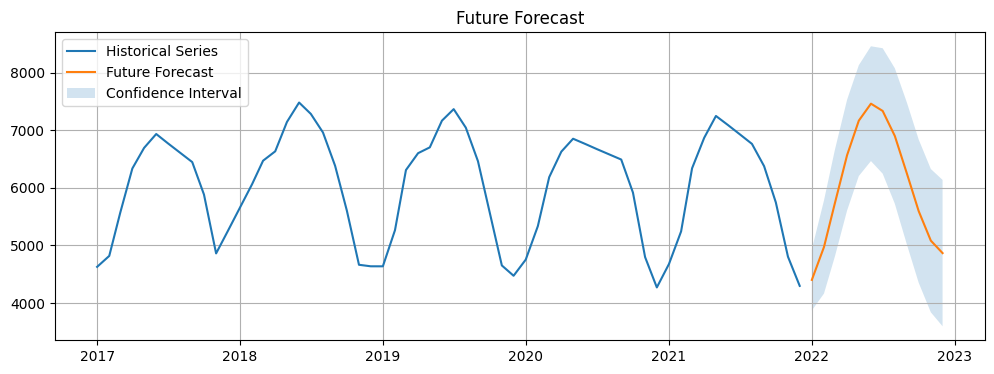

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(saudi_df['GHI (Wh/m2)'].index, saudi_df['GHI (Wh/m2)'].values, label="Historical Series")
plt.plot(future_mean.index, future_mean.values, label="Future Forecast")
plt.fill_between(future_mean.index, future_ci.iloc[:, 0], future_ci.iloc[:, 1], alpha=0.2, label="Confidence Interval")
plt.title("Future Forecast")
plt.legend()
plt.show()

## Importing Machine Learning Libraries

A suite of regression models will be employed for continuous-value forecasting, given that the underlying time series prediction task is a **Regression Problem**.

# Feature Engineering

In [ ]:
saudi_df.columns

Index(['GHI (Wh/m2)', 'DNI (Wh/m2)', 'DHI (Wh/m2)', 'Air Temperature (C°)',
       'Region_Group'],
      dtype='object')

In [ ]:
def create_ml_features_all(saudi_df, n_lags=12):
    all_features = []

    for col in saudi_df.columns:

        # Skip categorical (object-type) columns
        if saudi_df[col].dtype == 'object':
            continue

        series = saudi_df[col]

        df_ml = pd.DataFrame({f"{col}": series.copy()})

        # Lag Features
        for lag in range(1, n_lags + 1):
            df_ml[f"{col}_lag_{lag}"] = df_ml[col].shift(lag)

        # Rolling Window Features
        df_ml[f"{col}_rolling_mean_3"] = df_ml[col].shift(1).rolling(3).mean()
        df_ml[f"{col}_rolling_std_3"] = df_ml[col].shift(1).rolling(3).std()

        df_ml[f"{col}_rolling_mean_6"] = df_ml[col].shift(1).rolling(6).mean()
        df_ml[f"{col}_rolling_std_6"] = df_ml[col].shift(1).rolling(6).std()

        all_features.append(df_ml)

    # Concatenate all feature columns
    final_df = pd.concat(all_features, axis=1)

    # Calendar-based Time Features
    final_df["month"] = final_df.index.month
    final_df["quarter"] = final_df.index.quarter
    final_df["year"] = final_df.index.year

    # One-hot encode the Region_Group column
    final_df = pd.concat([final_df, pd.get_dummies(saudi_df["Region_Group"], drop_first=True)], axis=1)

    # Drop rows with missing values (introduced by lagging)
    final_df = final_df.dropna()

    return final_df

In [ ]:
ml_data = create_ml_features_all(saudi_df, n_lags=12)

print("Shape:", ml_data.shape)
display(ml_data.head())

Shape: (48, 71)


,GHI (Wh/m2),GHI (Wh/m2)_lag_1,GHI (Wh/m2)_lag_2,GHI (Wh/m2)_lag_3,GHI (Wh/m2)_lag_4,GHI (Wh/m2)_lag_5,GHI (Wh/m2)_lag_6,GHI (Wh/m2)_lag_7,GHI (Wh/m2)_lag_8,GHI (Wh/m2)_lag_9,...,Air Temperature (C°)_lag_10,Air Temperature (C°)_lag_11,Air Temperature (C°)_lag_12,Air Temperature (C°)_rolling_mean_3,Air Temperature (C°)_rolling_std_3,Air Temperature (C°)_rolling_mean_6,Air Temperature (C°)_rolling_std_6,month,quarter,year
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-01,5657.807821,5251.202207,4861.718816,5883.481661,6447.066410,6609.479402,6771.892395,6934.305387,6693.242913,6335.762814,...,22.500069,17.639120,18.769740,24.763127,2.578176,27.929268,3.832532,1,1,2018
2018-02-01,6064.413434,5657.807821,5251.202207,4861.718816,5883.481661,6447.066410,6609.479402,6771.892395,6934.305387,6693.242913,...,27.142188,22.500069,17.639120,23.471008,0.359498,26.726831,3.779622,2,1,2018
2018-03-01,6471.019048,6064.413434,5657.807821,5251.202207,4861.718816,5883.481661,6447.066410,6609.479402,6771.892395,6934.305387,...,30.295128,27.142188,22.500069,23.860302,0.459135,25.597502,3.177624,3,1,2018
2018-04-01,6633.605556,6471.019048,6064.413434,5657.807821,5251.202207,4861.718816,5883.481661,6447.066410,6609.479402,6771.892395,...,31.054443,30.295128,27.142188,24.319437,0.459135,24.541282,1.673970,4,2,2018
2018-05-01,7143.680159,6633.605556,6471.019048,6064.413434,5657.807821,5251.202207,4861.718816,5883.481661,6447.066410,6609.479402,...,31.074926,31.054443,30.295128,25.026585,0.858459,24.248797,1.035578,5,2,2018


In [ ]:
X_ml = ml_data.drop(columns=["GHI (Wh/m2)"])
y_ml = ml_data["GHI (Wh/m2)"]

print("X shape:", X_ml.shape)
print("y shape:", y_ml.shape)

X shape: (48, 70)
y shape: (48,)


## Train / Test Split

Random splitting is inappropriate for time series data, as the goal is to replicate real-world forecasting conditions:

- The model learns from historical (past) observations
- And then forecasts future values

Therefore, a **temporal split** is applied: the first 80% of the data is used for training and the remaining 20% for evaluation.

In [ ]:
split_idx_ml = int(len(ml_data) * 0.8) # 80-20

X_train_ml = X_ml.iloc[:split_idx_ml]
X_test_ml  = X_ml.iloc[split_idx_ml:]

y_train_ml = y_ml.iloc[:split_idx_ml]
y_test_ml  = y_ml.iloc[split_idx_ml:]

print("X_train shape:", X_train_ml.shape)
print("X_test shape :", X_test_ml.shape)
print("y_train shape:", y_train_ml.shape)
print("y_test shape :", y_test_ml.shape)

X_train shape: (38, 70)
X_test shape : (10, 70)
y_train shape: (38,)
y_test shape : (10,)


In [ ]:
baseline_ml_pred = X_test_ml["GHI (Wh/m2)_lag_1"].values

baseline_ml_rmse = rmse(y_test_ml.values, baseline_ml_pred)
baseline_ml_mae = mae(y_test_ml.values, baseline_ml_pred)

print("Baseline ML RMSE:", baseline_ml_rmse)
print("Baseline ML MAE :", baseline_ml_mae)

Baseline ML RMSE: 582.4189693137984
Baseline ML MAE : 495.3251301366372


## Linear Regression Model


In [ ]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train_ml, y_train_ml)

lr_pred = lr_model.predict(X_test_ml)

lr_rmse = rmse(y_test_ml.values, lr_pred)
lr_mae = mae(y_test_ml.values, lr_pred)

print("Linear Regression RMSE:", lr_rmse)
print("Linear Regression MAE :", lr_mae)

Linear Regression RMSE: 157.43641135968417
Linear Regression MAE : 119.15816012215774


## Decision Tree Regressor Model


In [ ]:
from sklearn.tree import DecisionTreeRegressor
dt_model = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_model.fit(X_train_ml, y_train_ml)

dt_pred = dt_model.predict(X_test_ml)

dt_rmse = rmse(y_test_ml.values, dt_pred)
dt_mae = mae(y_test_ml.values, dt_pred)

print("Decision Tree RMSE:", dt_rmse)
print("Decision Tree MAE :", dt_mae)

Decision Tree RMSE: 541.0288024195473
Decision Tree MAE : 414.92657254481975


## Random Forest Regressor Model


In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    random_state=42
)

rf_model.fit(X_train_ml, y_train_ml)

rf_pred = rf_model.predict(X_test_ml)

rf_rmse = rmse(y_test_ml.values, rf_pred)
rf_mae = mae(y_test_ml.values, rf_pred)

print("Random Forest RMSE:", rf_rmse)
print("Random Forest MAE :", rf_mae)

Random Forest RMSE: 304.08352912088475
Random Forest MAE : 236.00472889844067


## Gradient Boosting Regressor Model

This model operates by sequentially building an ensemble of weak learners, where each successive model corrects the residual errors of its predecessor.

It is widely recognized as a highly effective approach for regression tasks.

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
gbr_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gbr_model.fit(X_train_ml, y_train_ml)

gbr_pred = gbr_model.predict(X_test_ml)

gbr_rmse = rmse(y_test_ml.values, gbr_pred)
gbr_mae = mae(y_test_ml.values, gbr_pred)

print("Gradient Boosting RMSE:", gbr_rmse)
print("Gradient Boosting MAE :", gbr_mae)

Gradient Boosting RMSE: 415.63703314488845
Gradient Boosting MAE : 292.6840246878687


## XGBoost Model

In [ ]:
xgb_available = True

try:
    from xgboost import XGBRegressor
except:
    xgb_available = False
    print("XGBoost is not installed. Skipping XGBoost model.")

In [ ]:
if xgb_available:
    xgb_model = XGBRegressor(
        n_estimators=300, # Number of estimators (trees)
        learning_rate=0.05, # Learning rate
        max_depth=4, # Maximum tree depth
        subsample=0.8, # Row subsampling ratio — uses 80% of samples per tree
        colsample_bytree=0.8,
        random_state=42
    )

    xgb_model.fit(X_train_ml, y_train_ml)

    xgb_pred = xgb_model.predict(X_test_ml)

    xgb_rmse = rmse(y_test_ml.values, xgb_pred)
    xgb_mae = mae(y_test_ml.values, xgb_pred)

    print("XGBoost RMSE:", xgb_rmse)
    print("XGBoost MAE :", xgb_mae)

XGBoost RMSE: 267.84821622016767
XGBoost MAE : 215.1271896093962


## Actual vs. Predicted Values Comparison

The actual values will be plotted alongside each model's predictions to evaluate the following:

- How closely each model tracks the true series
- Whether the model captures peaks and troughs accurately
- Whether the predictions are overly smoothed

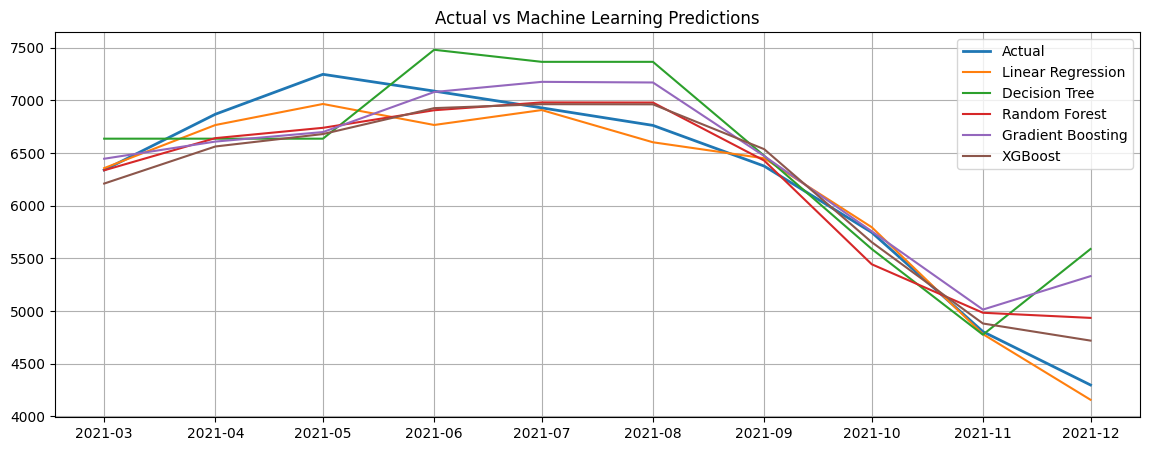

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(y_test_ml.index, y_test_ml.values, label="Actual", linewidth=2)
plt.plot(y_test_ml.index, lr_pred, label="Linear Regression")
plt.plot(y_test_ml.index, dt_pred, label="Decision Tree")
plt.plot(y_test_ml.index, rf_pred, label="Random Forest")
plt.plot(y_test_ml.index, gbr_pred, label="Gradient Boosting")

if xgb_available:
    plt.plot(y_test_ml.index, xgb_pred, label="XGBoost")

plt.title("Actual vs Machine Learning Predictions")
plt.legend()
plt.show()

## Machine Learning Model Comparison

Models are evaluated based on the following metrics:

- **RMSE**
- **MAE**

Lower values of these metrics indicate superior model performance.

In [ ]:
ml_results = [
    ["Baseline_ML", baseline_ml_rmse, baseline_ml_mae],
    ["Linear Regression", lr_rmse, lr_mae],
    ["Decision Tree", dt_rmse, dt_mae],
    ["Random Forest", rf_rmse, rf_mae],
    ["Gradient Boosting", gbr_rmse, gbr_mae]
]

if xgb_available:
    ml_results.append(["XGBoost", xgb_rmse, xgb_mae])

ml_results_df = pd.DataFrame(ml_results, columns=["Model", "RMSE", "MAE"])
ml_results_df = ml_results_df.sort_values("RMSE", ascending=True)

display(ml_results_df)

,Model,RMSE,MAE
1,Linear Regression,157.436411,119.158160
5,XGBoost,267.848216,215.127190
3,Random Forest,304.083529,236.004729
4,Gradient Boosting,415.637033,292.684025
2,Decision Tree,541.028802,414.926573
0,Baseline_ML,582.418969,495.325130


## Final Comparison: Statistical Models vs. Machine Learning Models

The results from both model families will now be consolidated:

- Statistical models
- Machine learning models

into a unified comparison table to determine the best-performing model overall.

In [ ]:
final_comparison = pd.DataFrame({
    "Model": [
        "Baseline",
        "ARMA",
        "ARIMA",
        "SARIMA",
        "Baseline_ML",
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "RMSE": [
        baseline_rmse,
        arma_rmse,
        arima_rmse,
        sarima_rmse,
        baseline_ml_rmse,
        lr_rmse,
        dt_rmse,
        rf_rmse,
        gbr_rmse
    ],
    "MAE": [
        baseline_mae,
        arma_mae,
        arima_mae,
        sarima_mae,
        baseline_ml_mae,
        lr_mae,
        dt_mae,
        rf_mae,
        gbr_mae
    ],
    "Type": [
        "Statistical",
        "Statistical",
        "Statistical",
        "Statistical",
        "Machine Learning",
        "Machine Learning",
        "Machine Learning",
        "Machine Learning",
        "Machine Learning"
    ]
})

if xgb_available:
    final_comparison.loc[len(final_comparison)] = [
        "XGBoost",
        xgb_rmse,
        xgb_mae,
        "Machine Learning"
    ]

final_comparison = final_comparison.sort_values("RMSE", ascending=True)
display(final_comparison)

,Model,RMSE,MAE,Type
5,Linear Regression,157.436411,119.158160,Machine Learning
9,XGBoost,267.848216,215.127190,Machine Learning
7,Random Forest,304.083529,236.004729,Machine Learning
2,ARIMA,359.248787,307.201266,Statistical
3,SARIMA,395.410531,339.350328,Statistical
8,Gradient Boosting,415.637033,292.684025,Machine Learning
1,ARMA,496.171777,423.840143,Statistical
0,Baseline,535.280813,436.885108,Statistical
6,Decision Tree,541.028802,414.926573,Machine Learning
4,Baseline_ML,582.418969,495.325130,Machine Learning


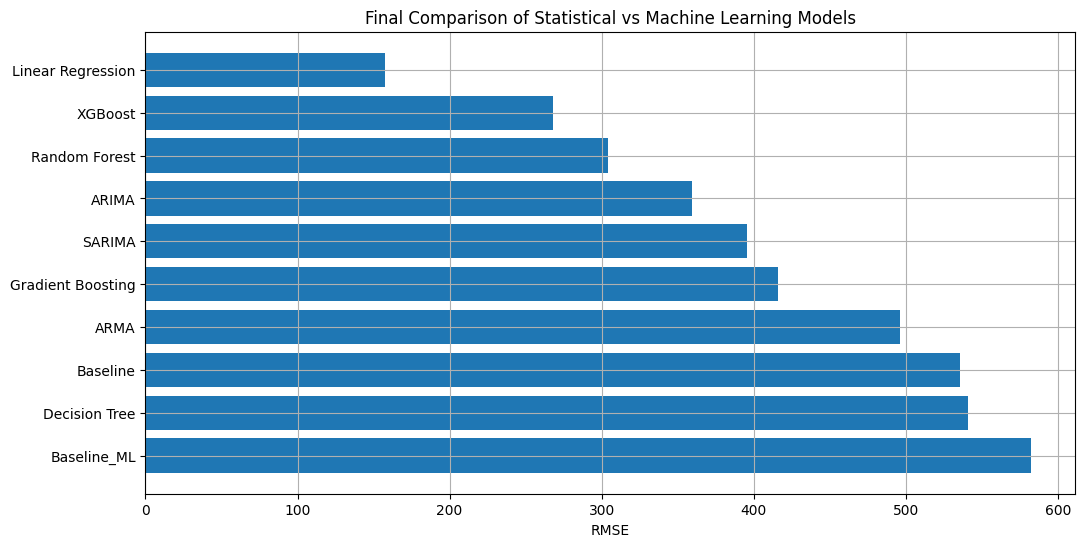

In [ ]:
plt.figure(figsize=(12, 6))
plt.barh(final_comparison["Model"], final_comparison["RMSE"])
plt.title("Final Comparison of Statistical vs Machine Learning Models")
plt.xlabel("RMSE")
plt.gca().invert_yaxis()
plt.show()

# Deep Learning

In [ ]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler

In [ ]:
series_values = saudi_df['GHI (Wh/m2)'].values.reshape(-1, 1) # 2D

scaler = MinMaxScaler()
series_scaled = scaler.fit_transform(series_values)

print("Original shape:", series_values.shape)
print("Scaled shape  :", series_scaled.shape)

Original shape: (60, 1)
Scaled shape  : (60, 1)


In [ ]:
def create_sequences(data, sequence_length=12): # sequence_length = number of months used as input window
    X, y = [], []

    for i in range(sequence_length, len(data)):
        X.append(data[i-sequence_length:i, 0])
        y.append(data[i, 0])

    X = np.array(X)
    y = np.array(y)

    return X, y

sequence_length = 12

X_dl, y_dl = create_sequences(series_scaled, sequence_length=sequence_length)

print("X_dl shape before reshape:", X_dl.shape)
print("y_dl shape:", y_dl.shape)

X_dl shape before reshape: (48, 12)
y_dl shape: (48,)


In [ ]:
X_dl = X_dl.reshape((X_dl.shape[0], X_dl.shape[1], 1))

print("X_dl shape after reshape:", X_dl.shape)

X_dl shape after reshape: (48, 12, 1)


In [ ]:
split_idx_dl = int(len(X_dl) * 0.8)

X_train_dl = X_dl[:split_idx_dl]
X_test_dl  = X_dl[split_idx_dl:]

y_train_dl = y_dl[:split_idx_dl]
y_test_dl  = y_dl[split_idx_dl:]

print("X_train_dl:", X_train_dl.shape)
print("X_test_dl :", X_test_dl.shape)
print("y_train_dl:", y_train_dl.shape)
print("y_test_dl :", y_test_dl.shape)

X_train_dl: (38, 12, 1)
X_test_dl : (10, 12, 1)
y_train_dl: (38,)
y_test_dl : (10,)


## Applying Early Stopping


In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

## Simple RNN Model


In [ ]:
rnn_model = Sequential([
    SimpleRNN(50, activation='tanh', input_shape=(sequence_length, 1)),
    Dropout(0.2),
    Dense(1)
])

rnn_model.compile(optimizer='adam', loss='mse')

rnn_history = rnn_model.fit(
    X_train_dl, y_train_dl,
    validation_split=0.1,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - loss: 0.8118 - val_loss: 0.1717
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.1947 - val_loss: 0.0138
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.0893 - val_loss: 0.0518
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 0.1079 - val_loss: 0.0778
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0947 - val_loss: 0.0516
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0578 - val_loss: 0.0238
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.0390 - val_loss: 0.0076
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 0.0382 - val_loss: 0.0036
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0593 - val_loss: 0.0028
Epoch 10/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0422 - val_loss: 0.0027
Epoch 11/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0325 - val_loss: 0.0030
Epoch 12/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0230 - val_loss

In [ ]:
rnn_pred_scaled = rnn_model.predict(X_test_dl)

rnn_pred = scaler.inverse_transform(rnn_pred_scaled)
y_test_actual = scaler.inverse_transform(y_test_dl.reshape(-1, 1))

rnn_rmse = rmse(y_test_actual.flatten(), rnn_pred.flatten())
rnn_mae = mae(y_test_actual.flatten(), rnn_pred.flatten())

print("Simple RNN RMSE:", rnn_rmse)
print("Simple RNN MAE :", rnn_mae)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step
Simple RNN RMSE: 312.93378507008856
Simple RNN MAE : 261.6913690177457


## LSTM Model


In [ ]:
lstm_model = Sequential([
    LSTM(64, activation='tanh', input_shape=(sequence_length, 1)),
    Dropout(0.2),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse')

lstm_history = lstm_model.fit(
    X_train_dl, y_train_dl,
    validation_split=0.1,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 369ms/step - loss: 0.3022 - val_loss: 0.0198
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.2019 - val_loss: 0.0661
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.1274 - val_loss: 0.1699
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.1011 - val_loss: 0.2894
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.1104 - val_loss: 0.2881
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.1139 - val_loss: 0.2499
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0798 - val_loss: 0.2330
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0968 - val_loss: 0.2179
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0910 - val_loss: 0.1976
Epoch 10/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.1063 - val_loss: 0.1920


In [ ]:
lstm_pred_scaled = lstm_model.predict(X_test_dl)

lstm_pred = scaler.inverse_transform(lstm_pred_scaled)

lstm_rmse = rmse(y_test_actual.flatten(), lstm_pred.flatten())
lstm_mae = mae(y_test_actual.flatten(), lstm_pred.flatten())

print("LSTM RMSE:", lstm_rmse)
print("LSTM MAE :", lstm_mae)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
LSTM RMSE: 1619.1150322776991
LSTM MAE : 1475.5620828882193


## GRU Model


In [ ]:
gru_model = Sequential([
    GRU(64, activation='tanh', input_shape=(sequence_length, 1)),
    Dropout(0.2),
    Dense(1)
])

gru_model.compile(optimizer='adam', loss='mse')

gru_history = gru_model.fit(
    X_train_dl, y_train_dl,
    validation_split=0.1,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step - loss: 0.3270 - val_loss: 0.0171
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.2257 - val_loss: 0.0306
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.1535 - val_loss: 0.0648
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.1036 - val_loss: 0.1209
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0894 - val_loss: 0.1878
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0939 - val_loss: 0.2370
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0916 - val_loss: 0.2299
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0916 - val_loss: 0.1962
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0901 - val_loss: 0.1648
Epoch 10/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0750 - val_loss: 0.1489


In [ ]:
gru_pred_scaled = gru_model.predict(X_test_dl)

gru_pred = scaler.inverse_transform(gru_pred_scaled)

gru_rmse = rmse(y_test_actual.flatten(), gru_pred.flatten())
gru_mae = mae(y_test_actual.flatten(), gru_pred.flatten())

print("GRU RMSE:", gru_rmse)
print("GRU MAE :", gru_mae)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
GRU RMSE: 1700.1277041191329
GRU MAE : 1519.1359598413442


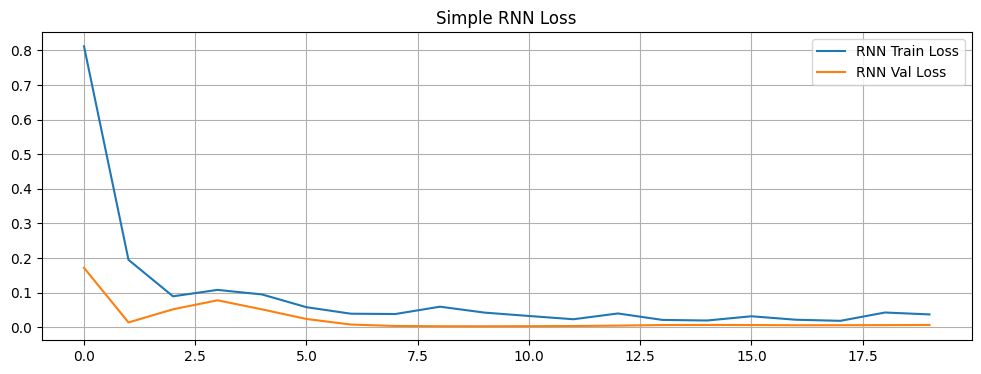

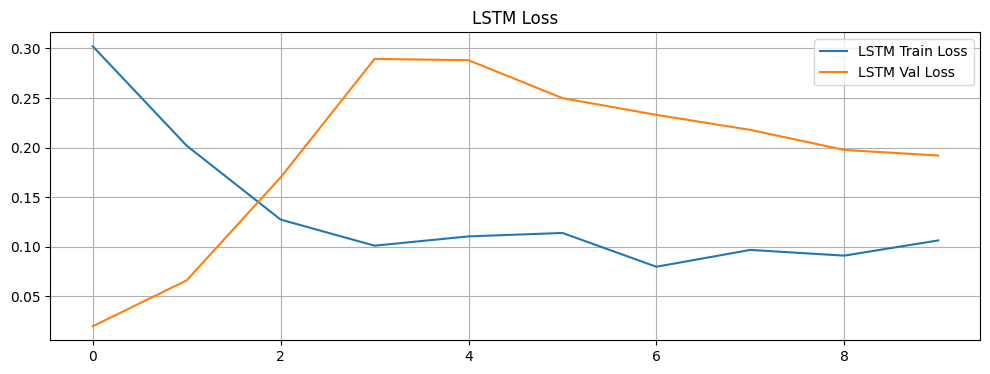

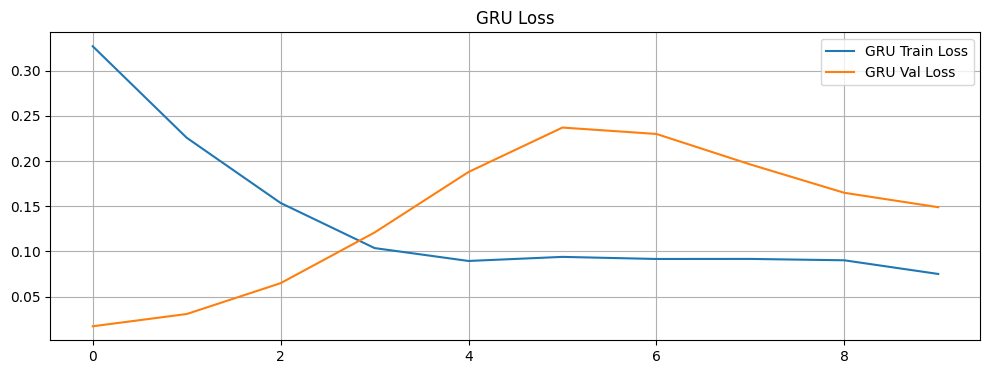

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(rnn_history.history['loss'], label='RNN Train Loss')
plt.plot(rnn_history.history['val_loss'], label='RNN Val Loss')
plt.title("Simple RNN Loss")
plt.legend()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(lstm_history.history['loss'], label='LSTM Train Loss')
plt.plot(lstm_history.history['val_loss'], label='LSTM Val Loss')
plt.title("LSTM Loss")
plt.legend()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(gru_history.history['loss'], label='GRU Train Loss')
plt.plot(gru_history.history['val_loss'], label='GRU Val Loss')
plt.title("GRU Loss")
plt.legend()
plt.show()

## Actual vs. Predicted Values — Deep Learning Models


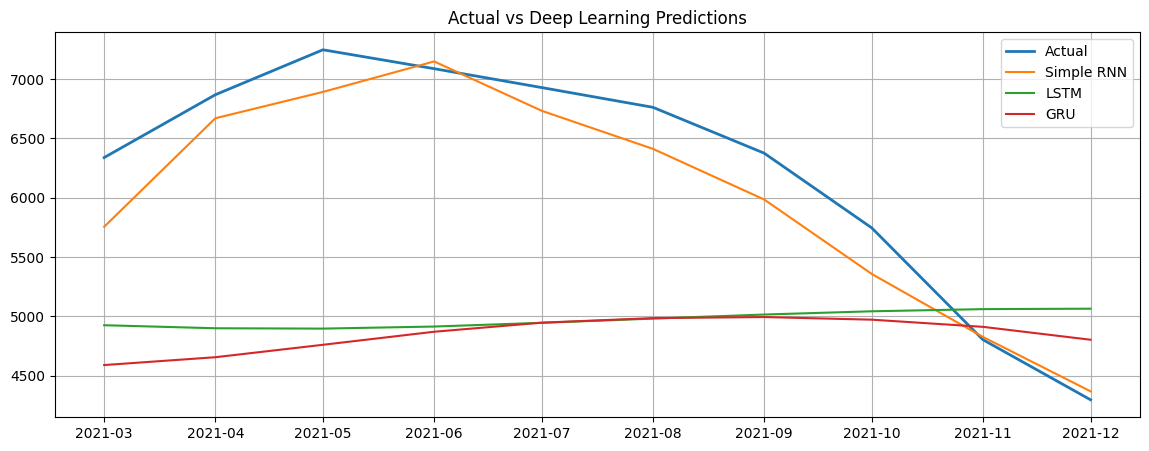

In [ ]:
test_index_dl = saudi_df['GHI (Wh/m2)'].index[sequence_length:][split_idx_dl:]

plt.figure(figsize=(14, 5))
plt.plot(test_index_dl, y_test_actual.flatten(), label="Actual", linewidth=2)
plt.plot(test_index_dl, rnn_pred.flatten(), label="Simple RNN")
plt.plot(test_index_dl, lstm_pred.flatten(), label="LSTM")
plt.plot(test_index_dl, gru_pred.flatten(), label="GRU")
plt.title("Actual vs Deep Learning Predictions")
plt.legend()
plt.show()

## Deep Learning Model Comparison

The three deep learning models will be compared using the following metrics:

- **RMSE**
- **MAE**

Lower metric values indicate better predictive performance.

In [ ]:
dl_results = pd.DataFrame({
    "Model": ["Simple RNN", "LSTM", "GRU"],
    "RMSE": [rnn_rmse, lstm_rmse, gru_rmse],
    "MAE": [rnn_mae, lstm_mae, gru_mae]
})

dl_results = dl_results.sort_values("RMSE", ascending=True)
display(dl_results)

,Model,RMSE,MAE
0,Simple RNN,312.933785,261.691369
1,LSTM,1619.115032,1475.562083
2,GRU,1700.127704,1519.135960


## Final Comparison: All Models

The deep learning results will now be appended to the previous results to enable a comprehensive comparison across all three model families:

- Statistical models
- Machine learning models
- Deep learning models

In [ ]:
deep_models_df = pd.DataFrame({
    "Model": ["Simple RNN", "LSTM", "GRU"],
    "RMSE": [rnn_rmse, lstm_rmse, gru_rmse],
    "MAE": [rnn_mae, lstm_mae, gru_mae],
    "Type": ["Deep Learning", "Deep Learning", "Deep Learning"]
})

all_models_comparison = pd.concat([final_comparison, deep_models_df], ignore_index=True)
all_models_comparison = all_models_comparison.sort_values("RMSE", ascending=True)

display(all_models_comparison)

,Model,RMSE,MAE,Type
0,Linear Regression,157.436411,119.158160,Machine Learning
1,XGBoost,267.848216,215.127190,Machine Learning
2,Random Forest,304.083529,236.004729,Machine Learning
10,Simple RNN,312.933785,261.691369,Deep Learning
3,ARIMA,359.248787,307.201266,Statistical
4,SARIMA,395.410531,339.350328,Statistical
5,Gradient Boosting,415.637033,292.684025,Machine Learning
6,ARMA,496.171777,423.840143,Statistical
7,Baseline,535.280813,436.885108,Statistical
8,Decision Tree,541.028802,414.926573,Machine Learning


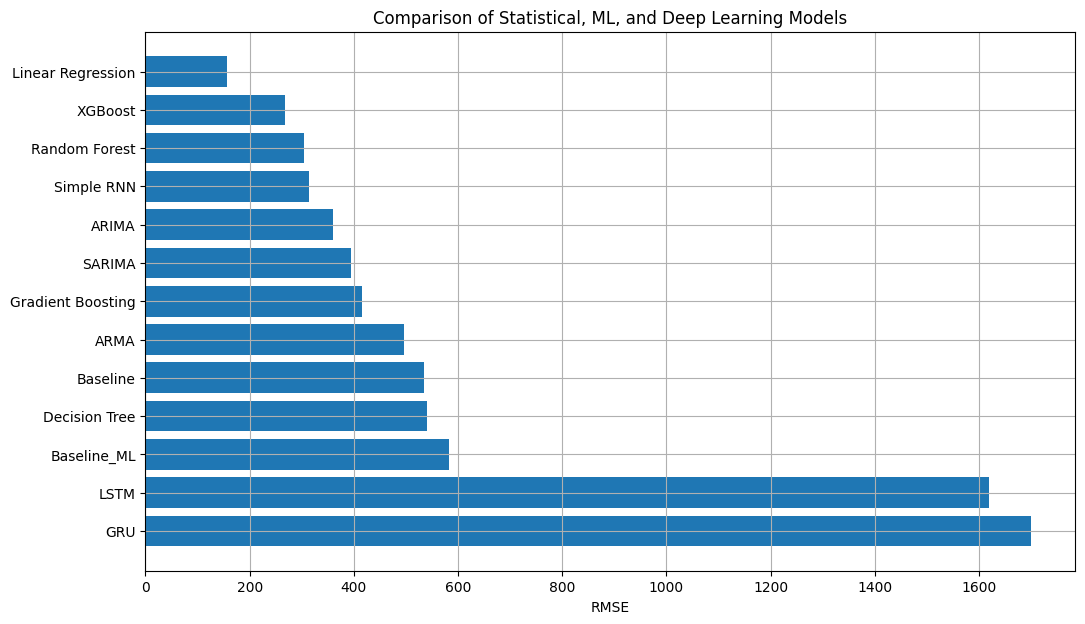

In [ ]:
plt.figure(figsize=(12, 7))
plt.barh(all_models_comparison["Model"], all_models_comparison["RMSE"])
plt.title("Comparison of Statistical, ML, and Deep Learning Models")
plt.xlabel("RMSE")
plt.gca().invert_yaxis()
plt.show()

## Final Best Model Selection

The overall best model will be selected based on the lowest **RMSE** value, followed by identifying its category:

- Statistical model
- Machine Learning
- Deep Learning

In [ ]:
best_model_overall = all_models_comparison.iloc[0]["Model"]
print("Best overall model:", best_model_overall)

Best overall model: Linear Regression


## Saving the Best Deep Learning Model


In [ ]:
if best_model_overall == "Simple RNN":
    best_dl_model = rnn_model
elif best_model_overall == "LSTM":
    best_dl_model = lstm_model
elif best_model_overall == "GRU":
    best_dl_model = gru_model
# elif best_model_overall == "Linear Regression":
#     best_dl_model = gru_model
else:
    best_dl_model = None

if best_dl_model is not None:
    best_dl_model.save("/content/drive/MyDrive/best_deep_learning_time_series_model.keras")
    print("Best deep learning model saved successfully.")
else:
    print("Best model is not a deep learning model.")

Best model is not a deep learning model.
